# Projeto: Previsão de Atraso e Cancelamento de Voos

Este notebook tem como objetivo realizar a inspeção inicial do dataset, avaliar a qualidade dos dados e identificar potenciais necessidades de preparação.

### Importação de Bibliotecas e Carregamento do Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# caminho do dataset no Kaggle
path = "/kaggle/input/datasets/nalisha/flight-delay-and-cancellation-data-1-million-2024/flight_data_2024.csv"

# carregar dataset
df = pd.read_csv(path)

# dimensão
df.shape

(1048575, 18)

### Estrutura e Tipo de Dados

In [2]:
# primeiras linhas
df.head()

# últimas linhas
df.tail()

# nomes das colunas
df.columns

Index(['year', 'month', 'day_of_month', 'day_of_week', 'fl_date', 'origin',
       'origin_city_name', 'origin_state_nm', 'dep_time', 'taxi_out',
       'wheels_off', 'wheels_on', 'taxi_in', 'cancelled', 'air_time',
       'distance', 'weather_delay', 'late_aircraft_delay'],
      dtype='object')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 18 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   year                 1048575 non-null  int64  
 1   month                1048575 non-null  int64  
 2   day_of_month         1048575 non-null  int64  
 3   day_of_week          1048575 non-null  int64  
 4   fl_date              1048575 non-null  object 
 5   origin               1048575 non-null  object 
 6   origin_city_name     1048575 non-null  object 
 7   origin_state_nm      1048575 non-null  object 
 8   dep_time             1026022 non-null  float64
 9   taxi_out             1025450 non-null  float64
 10  wheels_off           1025450 non-null  float64
 11  wheels_on            1024898 non-null  float64
 12  taxi_in              1024898 non-null  float64
 13  cancelled            1048575 non-null  int64  
 14  air_time             1022824 non-null  float64
 15

In [4]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print('Variáveis Numéricas:', list(num_cols))
print('\nVariáveis Categóricas:', list(cat_cols))

Variáveis Numéricas: ['year', 'month', 'day_of_month', 'day_of_week', 'dep_time', 'taxi_out', 'wheels_off', 'wheels_on', 'taxi_in', 'cancelled', 'air_time', 'distance', 'weather_delay', 'late_aircraft_delay']

Variáveis Categóricas: ['fl_date', 'origin', 'origin_city_name', 'origin_state_nm']


### Estatísticas Descritivas

In [5]:
#tirar notação cientifica
df.describe()


,year,month,day_of_month,day_of_week,dep_time,taxi_out,wheels_off,wheels_on,taxi_in,cancelled,air_time,distance,weather_delay,late_aircraft_delay
count,1048575.0,1.048575e+06,1.048575e+06,1.048575e+06,1.026022e+06,1.025450e+06,1.025450e+06,1.024898e+06,1.024898e+06,1.048575e+06,1.022824e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,2024.0,1.478081e+00,1.530512e+01,3.893483e+00,1.325074e+03,1.825012e+01,1.349996e+03,1.476156e+03,8.082517e+00,2.222635e-02,1.162270e+02,8.345389e+02,1.194321e+00,5.326660e+00
std,0.0,4.995196e-01,8.585503e+00,2.010038e+00,4.972990e+02,1.044025e+01,4.980426e+02,5.198682e+02,6.512591e+00,1.474190e-01,7.091204e+01,5.923104e+02,2.005819e+01,2.975676e+01
min,2024.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,8.000000e+00,3.100000e+01,0.000000e+00,0.000000e+00
25%,2024.0,1.000000e+00,8.000000e+00,2.000000e+00,9.110000e+02,1.200000e+01,9.290000e+02,1.058000e+03,4.000000e+00,0.000000e+00,6.400000e+01,4.020000e+02,0.000000e+00,0.000000e+00
50%,2024.0,1.000000e+00,1.500000e+01,4.000000e+00,1.323000e+03,1.500000e+01,1.337000e+03,1.510000e+03,6.000000e+00,0.000000e+00,1.000000e+02,6.920000e+02,0.000000e+00,0.000000e+00
75%,2024.0,2.000000e+00,2.300000e+01,6.000000e+00,1.736000e+03,2.100000e+01,1.750000e+03,1.914000e+03,9.000000e+00,0.000000e+00,1.470000e+02,1.069000e+03,0.000000e+00,0.000000e+00
max,2024.0,2.000000e+00,3.100000e+01,7.000000e+00,2.400000e+03,2.130000e+02,2.400000e+03,2.400000e+03,4.440000e+02,1.000000e+00,7.230000e+02,5.095000e+03,1.804000e+03,2.100000e+03


### Análise de Valores Nulos (Inteiro e %)

In [6]:
nulos = df.isnull().sum().to_frame(name='nulos_values')
nulos['percentage'] = (nulos['nulos_values'] / len(df)) * 100
nulos.sort_values(by='percentage', ascending=False)

,nulos_values,percentage
air_time,25751,2.455809
wheels_on,23677,2.258017
taxi_in,23677,2.258017
taxi_out,23125,2.205374
wheels_off,23125,2.205374
dep_time,22553,2.150824
month,0,0.000000
year,0,0.000000
day_of_month,0,0.000000
day_of_week,0,0.000000


### Verificação de Duplicados

In [7]:
print(f"Número de registos duplicados: {df.duplicated().sum()}")

Número de registos duplicados: 7401


### Análise da Variável Alvo (cancelled)

In [8]:
df['cancelled'].value_counts()

cancelled
0    1025269
1      23306
Name: count, dtype: int64

In [9]:
(df['cancelled'].value_counts(normalize=True) * 100)

cancelled
0    97.777365
1     2.222635
Name: proportion, dtype: float64

### Conversão de Variáveis Temporais

In [10]:
df['fl_date'] = pd.to_datetime(df['fl_date'])
df['flight_month'] = df['fl_date'].dt.month
df['flight_weekday'] = df['fl_date'].dt.weekday

df[['fl_date', 'flight_month', 'flight_weekday']].head()

,fl_date,flight_month,flight_weekday
0,2024-01-01,1,0
1,2024-01-01,1,0
2,2024-01-01,1,0
3,2024-01-01,1,0
4,2024-01-01,1,0


### Conversão de variáveis "Object"

In [11]:
cat_cols = ["origin", "origin_city_name", "origin_state_nm"]

for col in cat_cols:
    df[col] = df[col].astype("category")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 20 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   year                 1048575 non-null  int64         
 1   month                1048575 non-null  int64         
 2   day_of_month         1048575 non-null  int64         
 3   day_of_week          1048575 non-null  int64         
 4   fl_date              1048575 non-null  datetime64[ns]
 5   origin               1048575 non-null  category      
 6   origin_city_name     1048575 non-null  category      
 7   origin_state_nm      1048575 non-null  category      
 8   dep_time             1026022 non-null  float64       
 9   taxi_out             1025450 non-null  float64       
 10  wheels_off           1025450 non-null  float64       
 11  wheels_on            1024898 non-null  float64       
 12  taxi_in              1024898 non-null  float64       
 1

### Conclusões Preliminares

- O dataset contém 1.048.575 registos e 18 variáveis.
- Existem valores nulos associados maioritariamente a voos cancelados.
- A variável `cancelled` será utilizada como target principal.
- Observa-se possível desbalanceamento de classes.
- Será necessário tratamento de missing values e preparação de variáveis temporais.

Na próxima fase (M2), será realizada análise exploratória aprofundada e preparação dos dados.

## Análise Exploratória de Dados

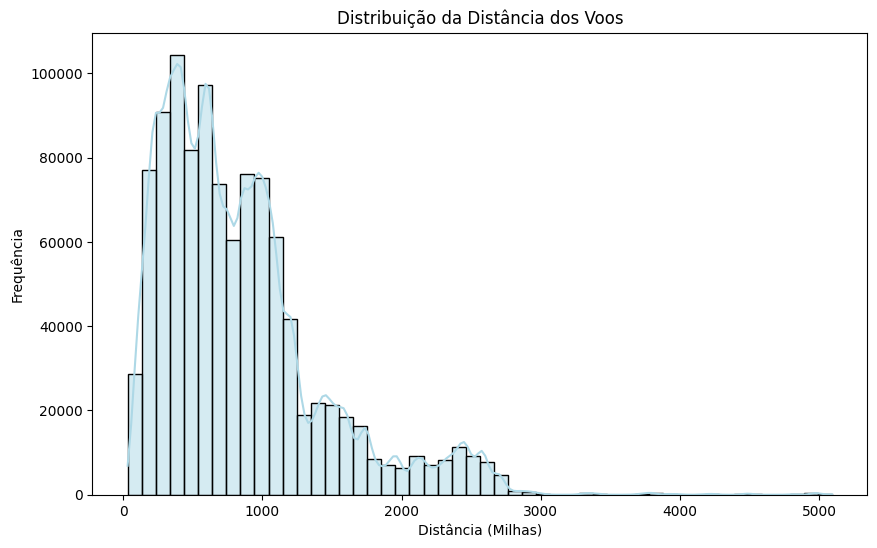

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(df['distance'], bins=50, kde=True, color='lightblue')
plt.title('Distribuição da Distância dos Voos')
plt.xlabel('Distância (Milhas)')
plt.ylabel('Frequência')
plt.show()

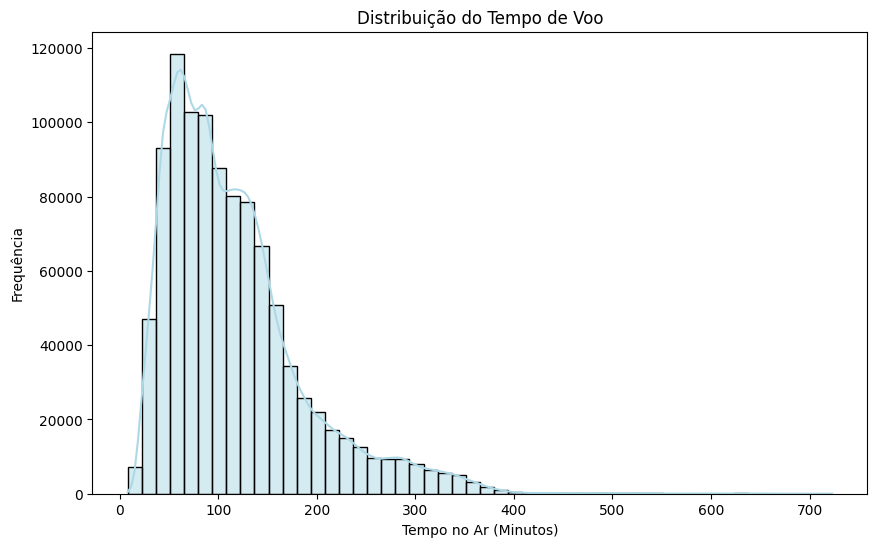

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(df['air_time'].dropna(), bins=50, kde=True, color='lightblue')
plt.title('Distribuição do Tempo de Voo')
plt.xlabel('Tempo no Ar (Minutos)')
plt.ylabel('Frequência')
plt.show()

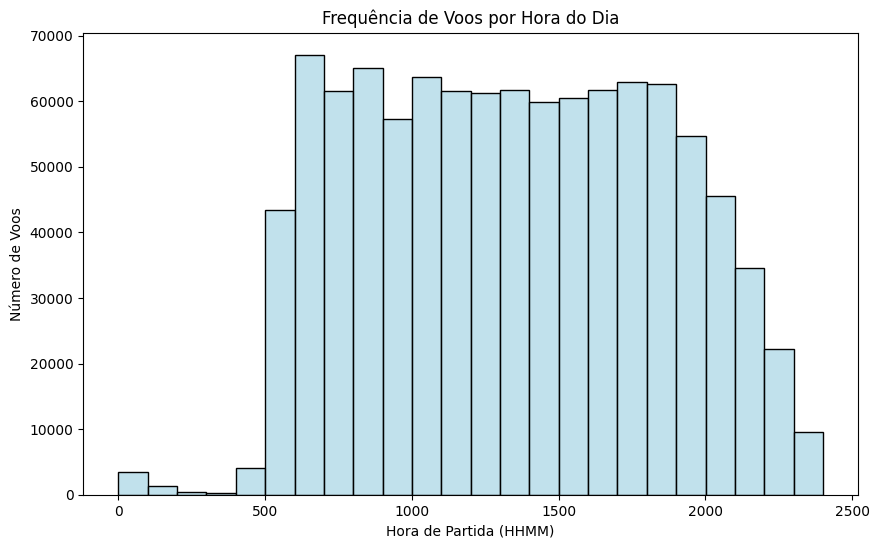

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(df['dep_time'].dropna(), bins=24, kde=False, color='lightblue')
plt.title('Frequência de Voos por Hora do Dia')
plt.xlabel('Hora de Partida (HHMM)')
plt.ylabel('Número de Voos')
plt.show()

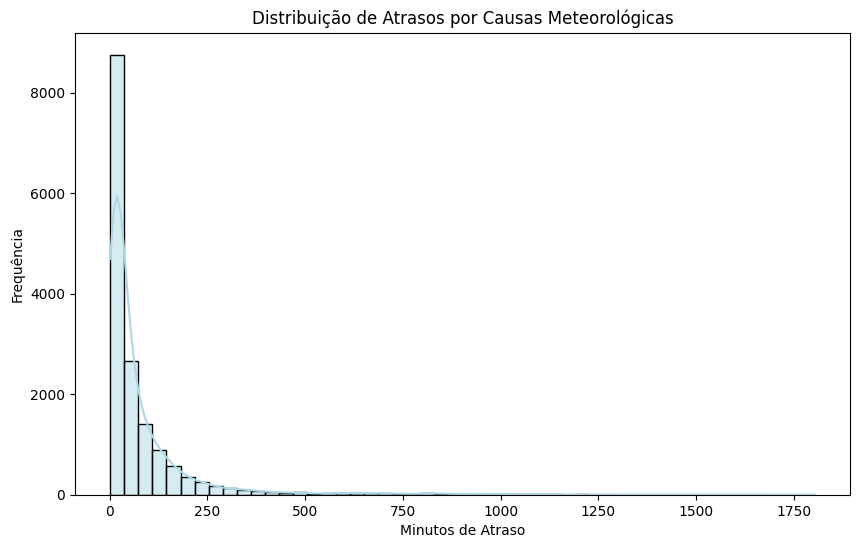

In [15]:
# Analisar apenas voos que efetivamente tiveram atraso meteorológico
atrasos_clima = df[df['weather_delay'] > 0]['weather_delay']

plt.figure(figsize=(10, 6))
sns.histplot(atrasos_clima, bins=50, kde=True, color='lightblue')
plt.title('Distribuição de Atrasos por Causas Meteorológicas')
plt.xlabel('Minutos de Atraso')
plt.ylabel('Frequência')
plt.show()

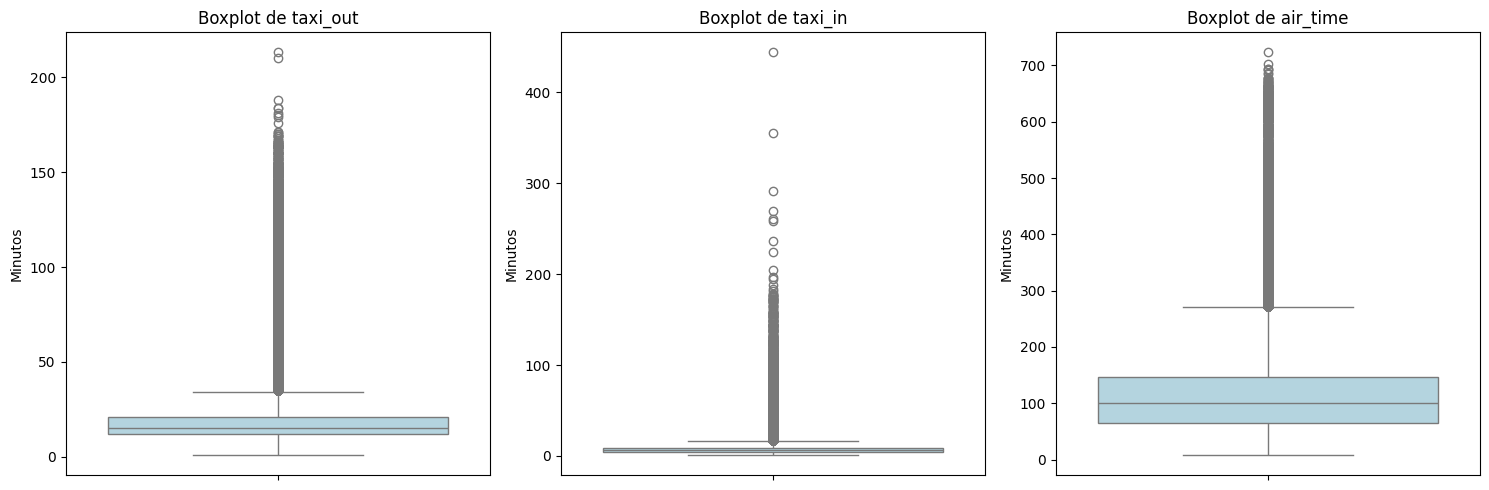

In [16]:
plt.figure(figsize=(15, 5))

# Lista de colunas operacionais
operacionais = ['taxi_out', 'taxi_in', 'air_time']

for i, col in enumerate(operacionais, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col].dropna(), color='lightblue')
    plt.title(f'Boxplot de {col}')
    plt.ylabel('Minutos')

plt.tight_layout()
plt.show()

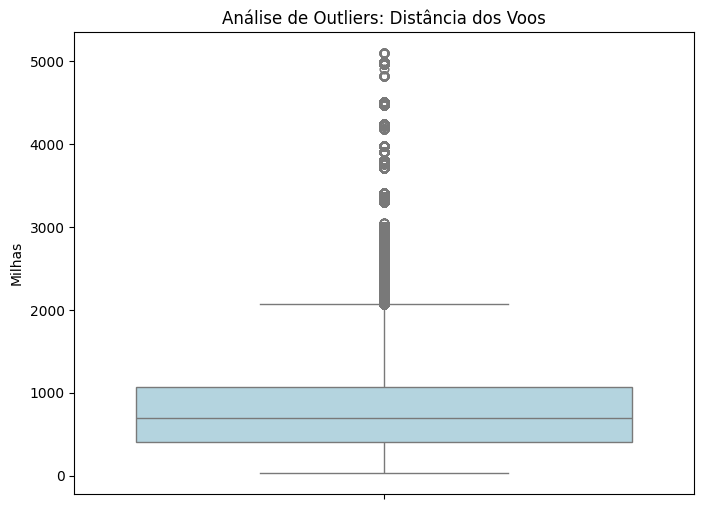

In [17]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['distance'], color='lightblue')
plt.title('Análise de Outliers: Distância dos Voos')
plt.ylabel('Milhas')
plt.show()

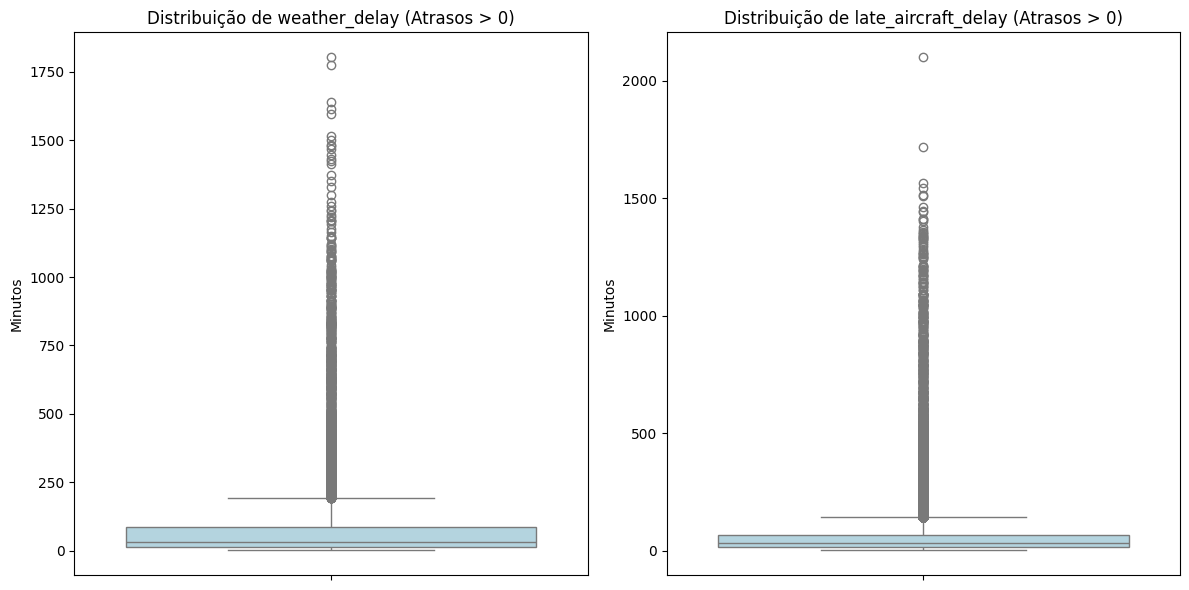

In [18]:
plt.figure(figsize=(12, 6))

# Analisar apenas onde o atraso é maior que 0 para ver a distribuição do erro
atrasos = ['weather_delay', 'late_aircraft_delay']

for i, col in enumerate(atrasos, 1):
    plt.subplot(1, 2, i)
    # Filtramos valores > 0 para conseguir visualizar a caixa
    sns.boxplot(y=df[df[col] > 0][col], color='lightblue')
    plt.title(f'Distribuição de {col} (Atrasos > 0)')
    plt.ylabel('Minutos')

plt.tight_layout()
plt.show()

### Frequência de Variáveis Categóricas

In [19]:
TOP_N = 10

# colunas categóricas
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

tables = {}

for col in cat_cols:
    freq = df[col].value_counts(dropna=False).head(TOP_N)
    perc = (df[col].value_counts(dropna=False, normalize=True).head(TOP_N) * 100).round(2)

    tables[col] = pd.DataFrame({
        "count": freq,
        "percentage_%": perc
    })

# juntar lado a lado (cada variável vira um "bloco" de colunas)
freq_side_by_side = pd.concat(tables, axis=1)

freq_side_by_side

origin              origin_city_name               \
                         count percentage_%            count percentage_%   
ATL                    50297.0         4.80              NaN          NaN   
DFW                    45521.0         4.34              NaN          NaN   
DEN                    44327.0         4.23              NaN          NaN   
ORD                    39179.0         3.74              NaN          NaN   
CLT                    31667.0         3.02              NaN          NaN   
PHX                    29683.0         2.83              NaN          NaN   
LAX                    28874.0         2.75              NaN          NaN   
LAS                    28492.0         2.72              NaN          NaN   
MCO                    27392.0         2.61              NaN          NaN   
LGA                    24990.0         2.38              NaN          NaN   
Atlanta, GA                NaN          NaN          50297.0         4.80   
Chicago, IL                NaN          NaN          50106.0         4.78   
Dallas/Fort Worth, TX      NaN          NaN          45521.0         4.34   
Denver, CO                 NaN          NaN          44327.0         4.23   
New York, NY               NaN          NaN          43428.0         4.14   
Charlotte, NC              NaN          NaN          31667.0         3.02   
Phoenix, AZ                NaN          NaN          30648.0         2.92   
Washington, DC             NaN          NaN          30007.0         2.86   
Los Angeles, CA            NaN          NaN          28874.0         2.75   
Las Vegas, NV              NaN          NaN          28492.0         2.72   
Texas                      NaN          NaN              NaN          NaN   
California                 NaN          NaN              NaN          NaN   
Florida                    NaN          NaN              NaN          NaN   
New York                   NaN          NaN              NaN          NaN   
Georgia                    NaN          NaN              NaN          NaN   
Illinois                   NaN          NaN              NaN          NaN   
Colorado                   NaN          NaN              NaN          NaN   
North Carolina             NaN          NaN              NaN          NaN   
Virginia                   NaN          NaN              NaN          NaN   
Arizona                    NaN          NaN              NaN          NaN   

                      origin_state_nm               
                                count percentage_%  
ATL                               NaN          NaN  
DFW                               NaN          NaN  
DEN                               NaN          NaN  
ORD                               NaN          NaN  
CLT                               NaN          NaN  
PHX                               NaN          NaN  
LAX                               NaN          NaN  
LAS                               NaN          NaN  
MCO                               NaN          NaN  
LGA                               NaN          NaN  
Atlanta, GA                       NaN          NaN  
Chicago, IL                       NaN          NaN  
Dallas/Fort Worth, TX             NaN          NaN  
Denver, CO                        NaN          NaN  
New York, NY                      NaN          NaN  
Charlotte, NC                     NaN          NaN  
Phoenix, AZ                       NaN          NaN  
Washington, DC                    NaN          NaN  
Los Angeles, CA                   NaN          NaN  
Las Vegas, NV                     NaN          NaN  
Texas                        110559.0        10.54  
California                   109161.0        10.41  
Florida                      108098.0        10.31  
New York                      55738.0         5.32  
Georgia                       53886.0         5.14  
Illinois                      52246.0         4.98  
Colorado                      51974.0         4.96  
North Carolina        

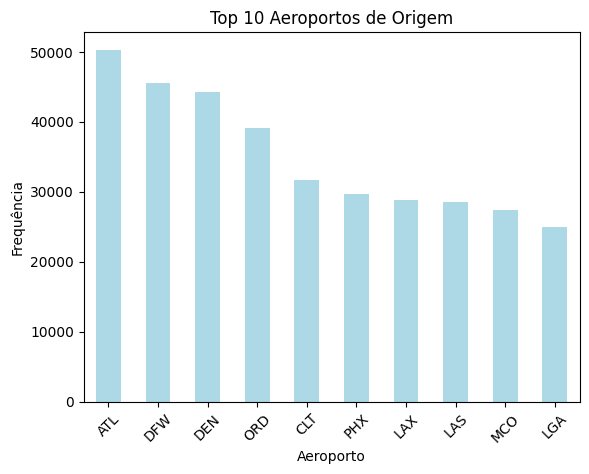

In [20]:
plt.figure()
df["origin"].value_counts().head(10).plot(kind="bar" , color='lightblue')
plt.title("Top 10 Aeroportos de Origem")
plt.xlabel("Aeroporto")
plt.ylabel("Frequência")
plt.xticks(rotation=45)
plt.show()

### Matriz de Correlação e Heatmap

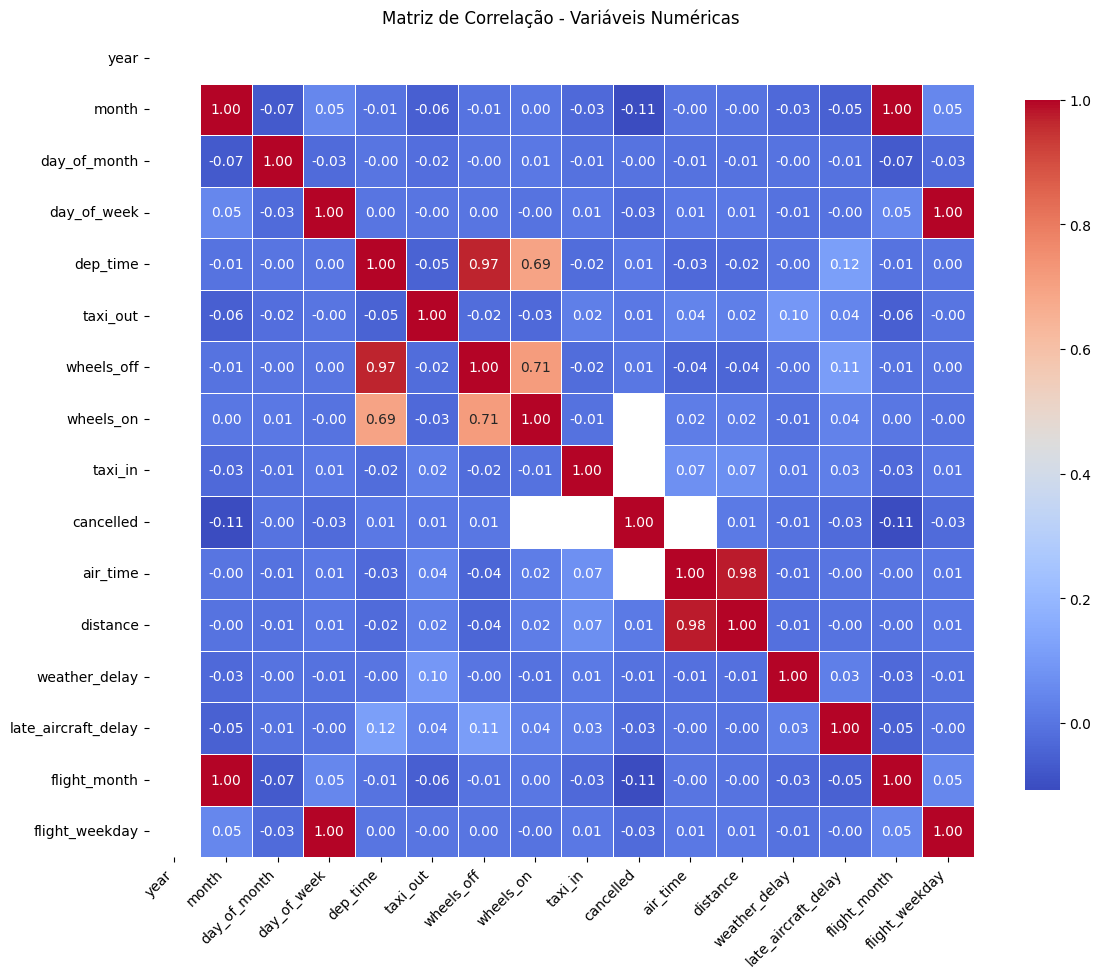

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# selecionar variáveis numéricas
num_cols = df.select_dtypes(include=["int64", "float64", "int32"]).columns
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    annot=True,          # mostra os valores
    fmt=".2f",           # 2 casas decimais
    cmap="coolwarm",
    linewidths=0.5,      # separação entre células
    square=True,         # células quadradas
    cbar_kws={"shrink": 0.8}
)

plt.title("Matriz de Correlação - Variáveis Numéricas")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Scatter Plots vs Variável Alvo

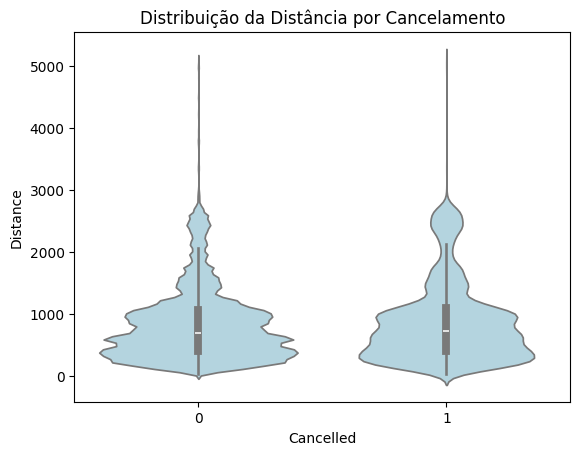

In [22]:
plt.figure()

sns.violinplot(x="cancelled", y="distance", data=df, color='lightblue')

plt.title("Distribuição da Distância por Cancelamento")
plt.xlabel("Cancelled")
plt.ylabel("Distance")

plt.show()

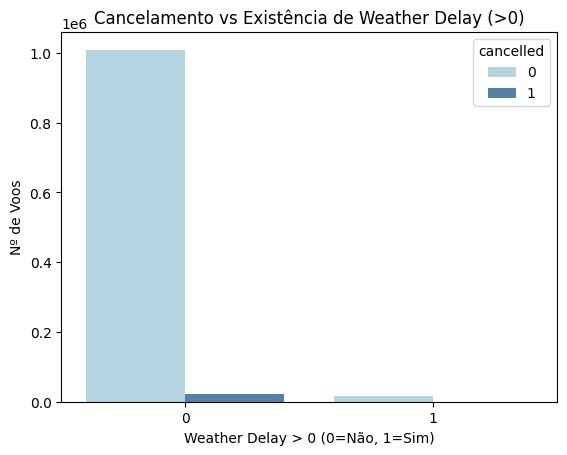

In [23]:
df["has_weather_delay"] = (df["weather_delay"] > 0).astype(int)

plt.figure()

sns.countplot(
    x="has_weather_delay",
    hue="cancelled",
    data=df,
    palette=["lightblue", "steelblue"]
)

plt.title("Cancelamento vs Existência de Weather Delay (>0)")
plt.xlabel("Weather Delay > 0 (0=Não, 1=Sim)")
plt.ylabel("Nº de Voos")

plt.show()

A análise mostra que a maioria dos voos apresenta weather_delay = 0. Os voos cancelados concentram-se principalmente neste grupo, enquanto voos com weather_delay > 0 raramente são cancelados. Isto sugere que o atraso meteorológico registado ocorre sobretudo em voos que efetivamente operaram, podendo representar informação posterior ao evento de cancelamento.

### Tratamento de Dados em Falta (Missing Data)

In [24]:
# Identificação de valores nulos

missing_values = df.isnull().sum()

missing_percentage = (missing_values / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": missing_percentage
})

missing_table = missing_table[missing_table["Missing Values"] > 0]

missing_table.sort_values("Percentage (%)", ascending=False)

,Missing Values,Percentage (%)
air_time,25751,2.455809
wheels_on,23677,2.258017
taxi_in,23677,2.258017
taxi_out,23125,2.205374
wheels_off,23125,2.205374
dep_time,22553,2.150824


In [25]:
# verificar relação entre missing e cancelamento

df.groupby("cancelled")[["dep_time","taxi_out","wheels_off","wheels_on","taxi_in","air_time"]].apply(lambda x: x.isnull().mean()*100)

,dep_time,taxi_out,wheels_off,wheels_on,taxi_in,air_time
cancelled,,,,,,
0,0.000000,0.000000,0.000000,0.036186,0.036186,0.238474
1,96.769072,99.223376,99.223376,100.000000,100.000000,100.000000


In [26]:
# remover voos cancelados para análise de delays

df_clean = df[df["cancelled"] == 0].copy()

df_clean.shape

(1025269, 21)

In [27]:
# verificar novamente os valores "Missing"

df_clean.isnull().sum()

year                      0
month                     0
day_of_month              0
day_of_week               0
fl_date                   0
origin                    0
origin_city_name          0
origin_state_nm           0
dep_time                  0
taxi_out                  0
wheels_off                0
wheels_on               371
taxi_in                 371
cancelled                 0
air_time               2445
distance                  0
weather_delay             0
late_aircraft_delay       0
flight_month              0
flight_weekday            0
has_weather_delay         0
dtype: int64

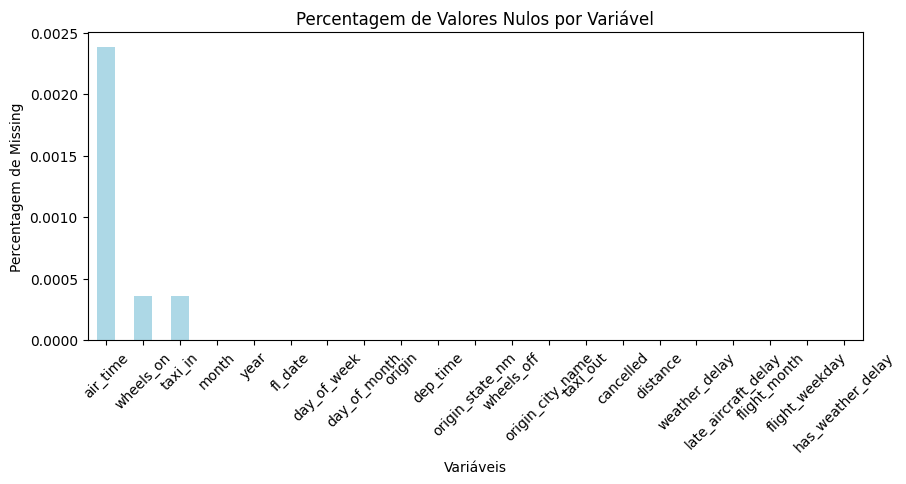

air_time               0.002385
wheels_on              0.000362
taxi_in                0.000362
month                  0.000000
year                   0.000000
fl_date                0.000000
day_of_week            0.000000
day_of_month           0.000000
origin                 0.000000
dep_time               0.000000
origin_state_nm        0.000000
wheels_off             0.000000
origin_city_name       0.000000
taxi_out               0.000000
cancelled              0.000000
distance               0.000000
weather_delay          0.000000
late_aircraft_delay    0.000000
flight_month           0.000000
flight_weekday         0.000000
has_weather_delay      0.000000
dtype: float64

In [28]:
# calcular percentagem de missing
missing_percentage = df_clean.isnull().mean().sort_values(ascending=False)

plt.figure(figsize=(10,4))

missing_percentage.plot(kind="bar", color='lightblue')

plt.title("Percentagem de Valores Nulos por Variável")
plt.ylabel("Percentagem de Missing")
plt.xlabel("Variáveis")
plt.xticks(rotation=45)

plt.show()

df_clean.isnull().mean().sort_values(ascending=False)

A análise mostra que apenas três variáveis apresentam valores nulos: `air_time`, `wheels_on` e `taxi_in`.  
No entanto, a percentagem de missing values é muito reduzida (inferior a 1%). O mapa de valores nulos confirma que estes casos são raros e estão concentrados em poucas observações.

### Tratamento de Outliers e Erros nos dados 

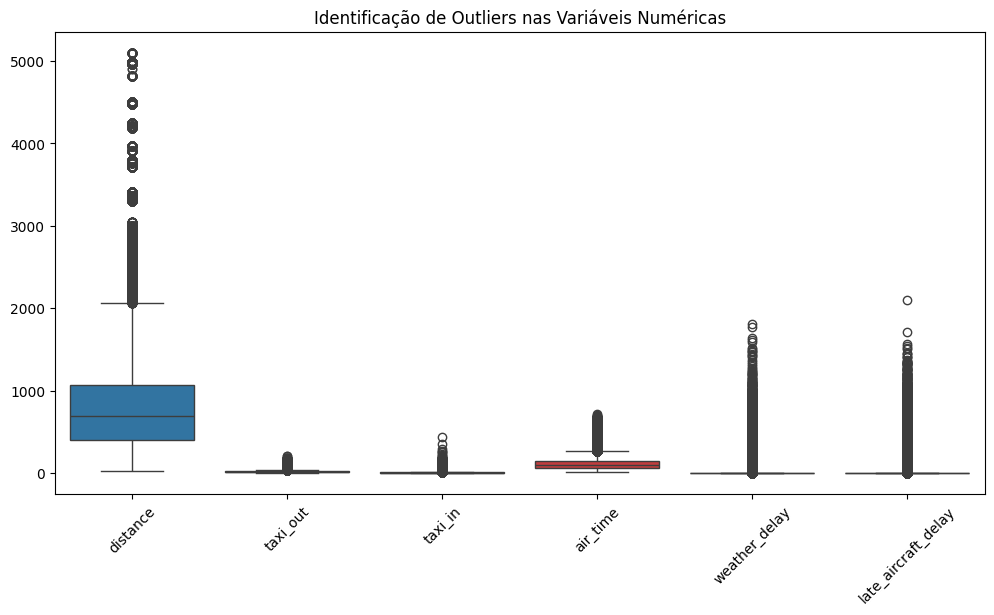

In [29]:
num_cols = [
    "distance",
    "taxi_out",
    "taxi_in",
    "air_time",
    "weather_delay",
    "late_aircraft_delay"
]

plt.figure(figsize=(12,6))

sns.boxplot(data=df_clean[num_cols])

plt.title("Identificação de Outliers nas Variáveis Numéricas")
plt.xticks(rotation=45)

plt.show()

In [30]:
outliers = {}

for col in num_cols:
    
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers[col] = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)].shape[0]

outliers

{'distance': 59292,
 'taxi_out': 61545,
 'taxi_in': 70946,
 'air_time': 48052,
 'weather_delay': 15895,
 'late_aircraft_delay': 99038}

Foram analisadas as principais variáveis numéricas através de boxplots e do método IQR para identificar valores atípicos.

Observou-se a presença de um número considerável de outliers, sobretudo nas variáveis `late_aircraft_delay`, `taxi_in` e `taxi_out`. Também existem valores extremos nas variáveis `distance`, `air_time` e `weather_delay`, embora em menor proporção.

No entanto, estes valores correspondem a situações operacionais reais (por exemplo, atrasos elevados ou voos de longa distância), não representando necessariamente erros de registo nos dados.

Assim, nesta fase optou-se por **manter estes valores no dataset**, uma vez que podem conter informação relevante para o modelo e refletem eventos reais no contexto da aviação.